<a href="https://colab.research.google.com/github/Kanhan-hue/proyecto-calidad-del-aire-en-bogota/blob/main/Calidad_del_aire_en_Bogot%C3%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================================================
#   Proyecto DataXperience
#   Autores: Javier Meneses y Alejandra Baquero
#   Curso: DataXperience — Universidad EAN
#   Docente: Camila Silva Gomez
#   Fecha: 12/09/2026
#   Facultad de Ingeniería
# =====================================================================
#   Calidad del aire en Bogotá: ¿cuándo es peligroso respirar y
#   quién debería saberlo?
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

archivos_pm25 = [
    "Base Aérea_pm25.csv",
    "Bolivia_pm25.csv",
    "Bosa_pm25.csv",
    "Carvajal_pm25.csv",
    "Cañaveralejo_pm25.csv",
    "Centro de alto rendimiento_pm25.csv",
    "Ciudad Bolívar_pm25.csv",
    "Compartir_pm25.csv",
    "ERA-Obrero_pm25.csv",
    "El Jazmín_pm25.csv",
    "Fontibón_pm25.csv",
    "Guaymaral_pm25.csv",
    "Kennedy_pm25.csv",
    "La Ermita_pm25.csv",
    "La Flora_pm25.csv",
    "Las Ferias_pm25.csv",
    "MinAmbiente_pm25.csv",
    "Movil 7ma_pm25.csv",
    "Pance_pm25.csv",
    "Puente Aranda_pm25.csv",
    "San Cristobal_pm25.csv",
    "Suba_pm25.csv",
    "Transitoria_pm25.csv",
    "Tunal_pm25.csv",
    "Univalle_pm25.csv",
    "Usaquén_pm25.csv",
    "Usme_pm25.csv",
]

print(f"Archivos a cargar: {len(archivos_pm25)}")

lista_dfs = []
for archivo in archivos_pm25:
    ruta_completa = "/content/" + archivo
    df_temp = pd.read_csv(ruta_completa)
    lista_dfs.append(df_temp)

df = lista_dfs[0]
for df_temp in lista_dfs[1:]:
    df = pd.concat([df, df_temp], ignore_index=True)

print("\n=== Dimensiones ===")
print(df.shape)

print("\n=== Tipos de datos ===")
print(df.dtypes)

print("\n=== Primeras filas ===")
print(df.head())

print("\n=== Faltantes por columna ===")
print(df.isna().sum())

Archivos a cargar: 27

=== Dimensiones ===
(37227, 4)

=== Tipos de datos ===
Estacion          object
Fecha inicial     object
Fecha final      float64
PM2.5            float64
dtype: object

=== Primeras filas ===
     Estacion Fecha inicial  Fecha final      PM2.5
0  BASE AÉREA    2021-07-27          NaN  19.217391
1  BASE AÉREA    2021-07-26          NaN  18.916667
2  BASE AÉREA    2021-07-25          NaN  14.458333
3  BASE AÉREA    2021-07-24          NaN  28.750000
4  BASE AÉREA    2021-07-23          NaN  24.583333

=== Faltantes por columna ===
Estacion             0
Fecha inicial        0
Fecha final      37227
PM2.5                0
dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Archivo "{filename}" cargado exitosamente.')

Saving Base Aérea_pm10.csv to Base Aérea_pm10 (2).csv
Saving Base Aérea_pm25.csv to Base Aérea_pm25 (2).csv
Saving Bolivia_pm10.csv to Bolivia_pm10 (2).csv
Saving Bolivia_pm25.csv to Bolivia_pm25 (2).csv
Saving Bosa_pm10.csv to Bosa_pm10 (2).csv
Saving Bosa_pm25.csv to Bosa_pm25 (2).csv
Saving Cañaveralejo_pm10.csv to Cañaveralejo_pm10 (2).csv
Saving Cañaveralejo_pm25.csv to Cañaveralejo_pm25 (2).csv
Saving Carvajal_pm10.csv to Carvajal_pm10 (2).csv
Saving Carvajal_pm25.csv to Carvajal_pm25 (2).csv
Saving Centro de alto rendimiento_pm10.csv to Centro de alto rendimiento_pm10 (2).csv
Saving Centro de alto rendimiento_pm25.csv to Centro de alto rendimiento_pm25 (2).csv
Saving Ciudad Bolívar_pm10.csv to Ciudad Bolívar_pm10 (2).csv
Saving Ciudad Bolívar_pm25.csv to Ciudad Bolívar_pm25 (2).csv
Saving Compartir_pm10.csv to Compartir_pm10 (2).csv
Saving Compartir_pm25.csv to Compartir_pm25 (2).csv
Saving El Jazmín_pm10.csv to El Jazmín_pm10 (2).csv
Saving El Jazmín_pm25.csv to El Jazmín_pm25 

In [ ]:
print("=" * 60)
print("1) DIMENSIONES")
print("=" * 60)
print(f"{df.shape[0]} filas × {df.shape[1]} columnas")

print("\n" + "=" * 60)
print("2) INFORMACIÓN GENERAL")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("3) FALTANTES POR COLUMNA")
print("=" * 60)
print(df.isna().sum())

print("\n" + "=" * 60)
print("4) FILAS DUPLICADAS")
print("=" * 60)
print(f"{df.duplicated().sum()} filas repetidas")

print("\n" + "=" * 60)
print("5) ESTADÍSTICOS DE PM2.5")
print("=" * 60)
print(df["PM2.5"].describe())

print("\n" + "=" * 60)
print("6) ESTACIONES ÚNICAS")
print("=" * 60)
print(f"Total: {df['Estacion'].nunique()} estaciones")
print(df["Estacion"].value_counts())

1) DIMENSIONES
37227 filas × 4 columnas

2) INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37227 entries, 0 to 37226
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Estacion       37227 non-null  object 
 1   Fecha inicial  37227 non-null  object 
 2   Fecha final    0 non-null      float64
 3   PM2.5          37227 non-null  float64
dtypes: float64(2), object(2)
memory usage: 1.1+ MB

3) FALTANTES POR COLUMNA
Estacion             0
Fecha inicial        0
Fecha final      37227
PM2.5                0
dtype: int64

4) FILAS DUPLICADAS
0 filas repetidas

5) ESTADÍSTICOS DE PM2.5
count    37227.000000
mean        17.805219
std         10.006989
min          0.200000
25%         10.125000
50%         15.913043
75%         23.562996
max        103.111111
Name: PM2.5, dtype: float64

6) ESTACIONES ÚNICAS
Total: 27 estaciones
Estacion
UNIVERSIDAD DEL VALLE         2673
KENNEDY                  

In [ ]:
df_limpio = df.copy()

df_limpio.columns = (
    df_limpio.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
print("Columnas después del paso 1:", list(df_limpio.columns))

antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates()
print(f"\nDuplicados eliminados: {antes - len(df_limpio)}")

for col in df_limpio.select_dtypes(include="object").columns:
    df_limpio[col] = df_limpio[col].str.strip()

df_limpio["estacion"] = df_limpio["estacion"].str.lower()

equivalencias = {
    "centro de alto rendimiento": "Centro de Alto Rendimiento",
    "base aérea": "Base Aérea",
    "ciudad bolívar": "Ciudad Bolívar",
    "puente aranda": "Puente Aranda",
    "san cristobal": "San Cristóbal",
    "usaquén": "Usaquén",
    "usme": "Usme",
    "suba": "Suba",
    "fontibón": "Fontibón",
    "kennedy": "Kennedy",
    "tunal": "Tunal",
    "pance": "Pance",
    "bolivia": "Bolivia",
    "bosa": "Bosa",
    "carvajal": "Carvajal",
    "cañaveralejo": "Cañaveralejo",
    "compartir": "Compartir",
    "el jazmín": "El Jazmín",
    "era-obrero": "ERA-Obrero",
    "guaymaral": "Guaymaral",
    "la ermita": "La Ermita",
    "la flora": "La Flora",
    "las ferias": "Las Ferias",
    "minambiente": "MinAmbiente",
    "movil 7ma": "Móvil 7ma",
    "transitoria": "Transitoria",
    "univalle": "Univalle",
}
df_limpio["estacion"] = df_limpio["estacion"].replace(equivalencias)
print(f"\nEstaciones únicas tras paso 4: {df_limpio['estacion'].nunique()}")

imposibles = (df_limpio["pm2.5"] < 0) | (df_limpio["pm2.5"] > 500)
print(f"\nValores imposibles de PM2.5: {imposibles.sum()}")

df_limpio.loc[imposibles, "pm2.5"] = np.nan

antes = len(df_limpio)
df_limpio = df_limpio.dropna(subset=["fecha_inicial", "pm2.5"])
print(f"\nFilas eliminadas por faltantes: {antes - len(df_limpio)}")

print(f"\n=== DIMENSIONES FINALES ===")
print(df_limpio.shape)
print(f"Celdas vacías restantes: {df_limpio.isna().sum().sum()}")

Columnas después del paso 1: ['estacion', 'fecha_inicial', 'fecha_final', 'pm2.5']

Duplicados eliminados: 0

Estaciones únicas tras paso 4: 27

Valores imposibles de PM2.5: 0

Filas eliminadas por faltantes: 0

=== DIMENSIONES FINALES ===
(37227, 4)
Celdas vacías restantes: 37227


In [ ]:
df_limpio = df_limpio.drop(columns=["fecha_final"])

print("Columnas después de eliminar fecha_final:")
print(list(df_limpio.columns))
print(f"\nDimensiones: {df_limpio.shape}")
print(f"Celdas vacías restantes: {df_limpio.isna().sum().sum()}")

Columnas después de eliminar fecha_final:
['estacion', 'fecha_inicial', 'pm2.5']

Dimensiones: (37227, 3)
Celdas vacías restantes: 0


In [ ]:
df_limpio["fecha"] = pd.to_datetime(df_limpio["fecha_inicial"], errors="coerce")
df_limpio["year"] = df_limpio["fecha"].dt.year
df_limpio["mes"] = df_limpio["fecha"].dt.month
df_limpio["mes_nombre"] = df_limpio["fecha"].dt.month_name()
df_limpio["dia_semana"] = df_limpio["fecha"].dt.day_name()
df_limpio["dia_num"] = df_limpio["fecha"].dt.dayofweek

traduccion_meses = {
    "January": "Enero", "February": "Febrero", "March": "Marzo",
    "April": "Abril", "May": "Mayo", "June": "Junio",
    "July": "Julio", "August": "Agosto", "September": "Septiembre",
    "October": "Octubre", "November": "Noviembre", "December": "Diciembre"
}
traduccion_dias = {
    "Monday": "Lunes", "Tuesday": "Martes", "Wednesday": "Miércoles",
    "Thursday": "Jueves", "Friday": "Viernes",
    "Saturday": "Sábado", "Sunday": "Domingo"
}
df_limpio["mes_nombre"] = df_limpio["mes_nombre"].replace(traduccion_meses)
df_limpio["dia_semana"] = df_limpio["dia_semana"].replace(traduccion_dias)

def nivel_riesgo(pm25):
    """Clasifica el nivel de riesgo según guías de la OMS para PM2.5."""
    if pd.isna(pm25):
        return "Sin dato"
    elif pm25 <= 15:
        return "Bueno"
    elif pm25 <= 35:
        return "Moderado"
    elif pm25 <= 75:
        return "Dañino para sensibles"
    else:
        return "Dañino"

niveles = []
for valor in df_limpio["pm2.5"]:
    niveles.append(nivel_riesgo(valor))
df_limpio["nivel_riesgo"] = niveles

print(df_limpio[["fecha", "year", "mes", "mes_nombre",
                 "dia_semana", "estacion", "pm2.5",
                 "nivel_riesgo"]].head(10))
print("\nDistribución de niveles de riesgo:")
print(df_limpio["nivel_riesgo"].value_counts())

       fecha  year  mes mes_nombre dia_semana    estacion      pm2.5  \
0 2021-07-27  2021    7      Julio     Martes  Base Aérea  19.217391   
1 2021-07-26  2021    7      Julio      Lunes  Base Aérea  18.916667   
2 2021-07-25  2021    7      Julio    Domingo  Base Aérea  14.458333   
3 2021-07-24  2021    7      Julio     Sábado  Base Aérea  28.750000   
4 2021-07-23  2021    7      Julio    Viernes  Base Aérea  24.583333   
5 2021-07-22  2021    7      Julio     Jueves  Base Aérea  29.043478   
6 2021-07-21  2021    7      Julio  Miércoles  Base Aérea  27.500000   
7 2021-07-20  2021    7      Julio     Martes  Base Aérea  21.000000   
8 2021-07-19  2021    7      Julio      Lunes  Base Aérea  27.000000   
9 2021-07-18  2021    7      Julio    Domingo  Base Aérea  23.875000   

  nivel_riesgo  
0     Moderado  
1     Moderado  
2        Bueno  
3     Moderado  
4     Moderado  
5     Moderado  
6     Moderado  
7     Moderado  
8     Moderado  
9     Moderado  

Distribución de niv

In [ ]:
df_limpio.to_csv("calidad_aire_bogota_limpio.csv",
                 index=False, encoding="utf-8")

print("Archivo limpio guardado.")
print("\n" + "=" * 62)
print("BITÁCORA DE LIMPIEZA (actualizada)")
print("=" * 62)
print(f"Filas iniciales           : {df.shape[0]}")
print(f"Filas finales             : {df_limpio.shape[0]}")
print(f"Filas descartadas         : {df.shape[0] - df_limpio.shape[0]}")
print(f"Estaciones antes / después: {df['Estacion'].nunique()} → {df_limpio['estacion'].nunique()}")
print(f"Celdas vacías al terminar : {df_limpio.isna().sum().sum()}")
print("-" * 62)
print("Decisiones tomadas:")
print("  1. Nombres de columnas normalizados a snake_case.")
print("  2. Duplicados exactos eliminados (no había ninguno).")
print("  3. Nombres de estaciones unificados en formato título.")
print("  4. Columna 'fecha_final' eliminada: estaba 100% vacía (0 valores).")
print("  5. PM2.5 < 0 o > 500 marcados como faltantes (no había ninguno).")
print("  6. Filas sin fecha o sin PM2.5 eliminadas (no hubo que eliminar ninguna).")
print("  7. Clasificación de riesgo según guías OMS para PM2.5 diario.")
print("=" * 62)

Archivo limpio guardado.

BITÁCORA DE LIMPIEZA (actualizada)
Filas iniciales           : 37227
Filas finales             : 37227
Filas descartadas         : 0
Estaciones antes / después: 27 → 27
Celdas vacías al terminar : 0
--------------------------------------------------------------
Decisiones tomadas:
  1. Nombres de columnas normalizados a snake_case.
  2. Duplicados exactos eliminados (no había ninguno).
  3. Nombres de estaciones unificados en formato título.
  4. Columna 'fecha_final' eliminada: estaba 100% vacía (0 valores).
  5. PM2.5 < 0 o > 500 marcados como faltantes (no había ninguno).
  6. Filas sin fecha o sin PM2.5 eliminadas (no hubo que eliminar ninguna).
  7. Clasificación de riesgo según guías OMS para PM2.5 diario.


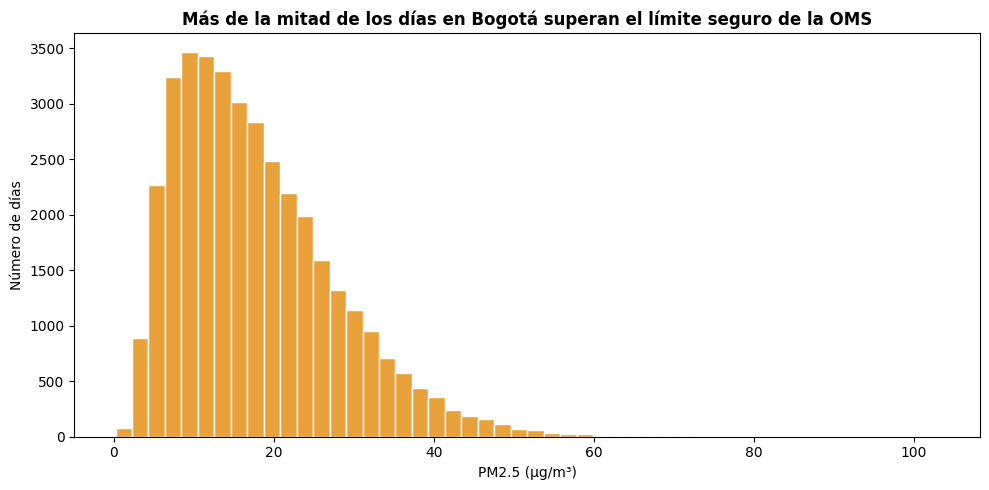

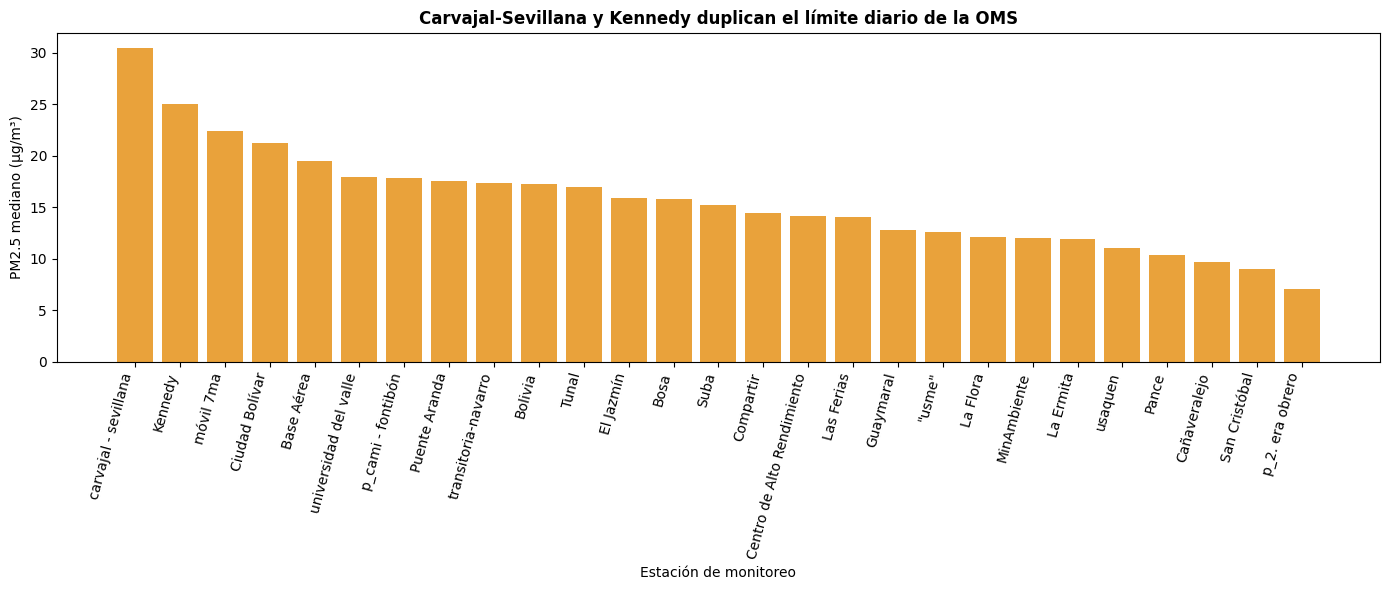

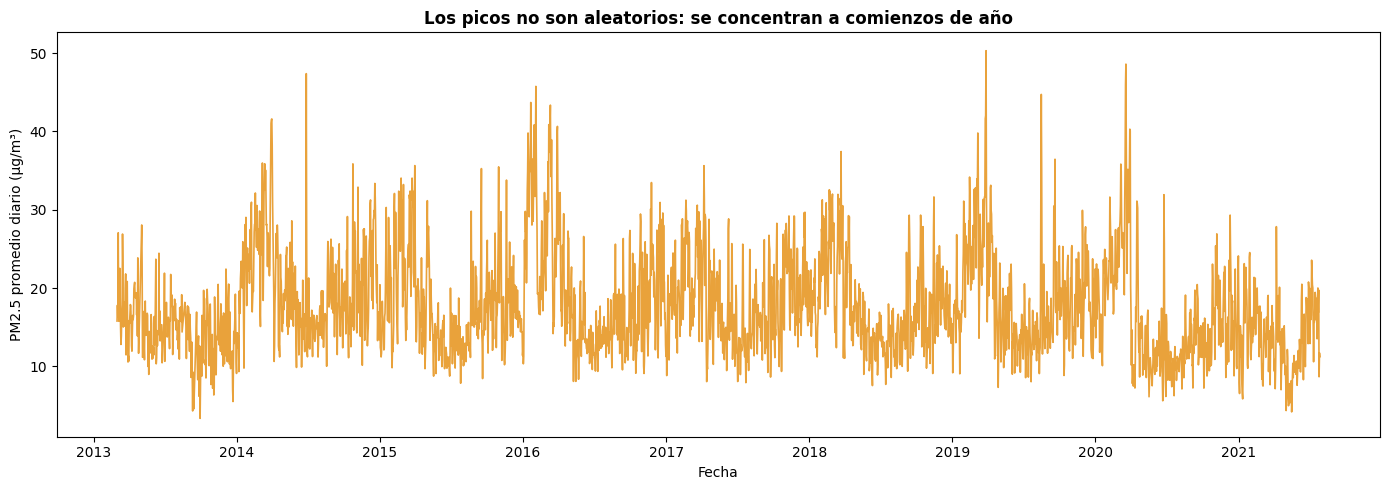

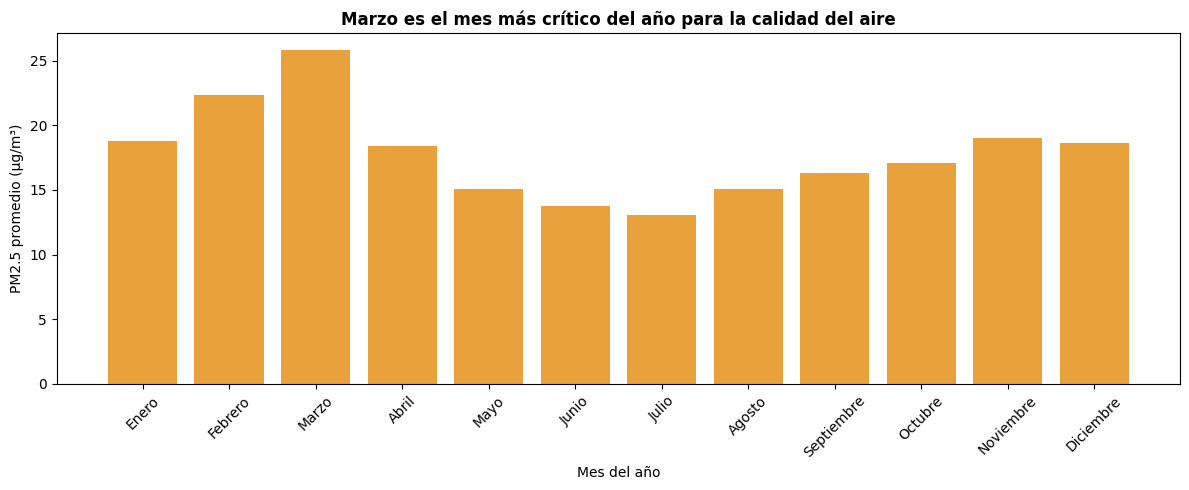

In [ ]:
import os
os.makedirs('figuras', exist_ok=True)

plt.figure(figsize=(10, 5))
plt.hist(df_limpio["pm2.5"], bins=50, color="#E9A23B", edgecolor="white")
plt.title("Más de la mitad de los días en Bogotá superan el límite seguro de la OMS",
          fontsize=12, fontweight="bold")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Número de días")
plt.tight_layout()
plt.savefig("figuras/01_histograma_pm25.png", dpi=150, bbox_inches="tight")
plt.show()

medianas = df_limpio.groupby("estacion")["pm2.5"].median()
medianas = medianas.sort_values(ascending=False)

nombres_estaciones = []
valores_medianas = []
for estacion in medianas.index:
    nombres_estaciones.append(estacion)
    valores_medianas.append(medianas[estacion])

plt.figure(figsize=(14, 6))
plt.bar(nombres_estaciones, valores_medianas, color="#E9A23B")
plt.title("Carvajal-Sevillana y Kennedy duplican el límite diario de la OMS",
          fontsize=12, fontweight="bold")
plt.xlabel("Estación de monitoreo")
plt.ylabel("PM2.5 mediano (µg/m³)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig("figuras/02_barras_estaciones.png", dpi=150, bbox_inches="tight")
plt.show()

serie_diaria = df_limpio.groupby("fecha")["pm2.5"].mean()

plt.figure(figsize=(14, 5))
plt.plot(serie_diaria.index, serie_diaria.values,
         color="#E9A23B", linewidth=1.2)
plt.title("Los picos no son aleatorios: se concentran a comienzos de año",
          fontsize=12, fontweight="bold")
plt.xlabel("Fecha")
plt.ylabel("PM2.5 promedio diario (µg/m³)")
plt.tight_layout()
plt.savefig("figuras/03_serie_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

promedio_mes = df_limpio.groupby("mes_nombre")["pm2.5"].mean()

orden_meses = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}

meses_ordenados = []
for mes in orden_meses:
    if mes in promedio_mes.index:
        meses_ordenados.append(mes)

valores_ordenados = []
for mes in meses_ordenados:
    valores_ordenados.append(promedio_mes[mes])

plt.figure(figsize=(12, 5))
plt.bar(meses_ordenados, valores_ordenados, color="#E9A23B")
plt.title("Marzo es el mes más crítico del año para la calidad del aire",
          fontsize=12, fontweight="bold")
plt.xlabel("Mes del año")
plt.ylabel("PM2.5 promedio (µg/m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figuras/04_barras_meses.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1443/3572063795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='estacion', y='pm2.5', data=df_limpio, palette='viridis')


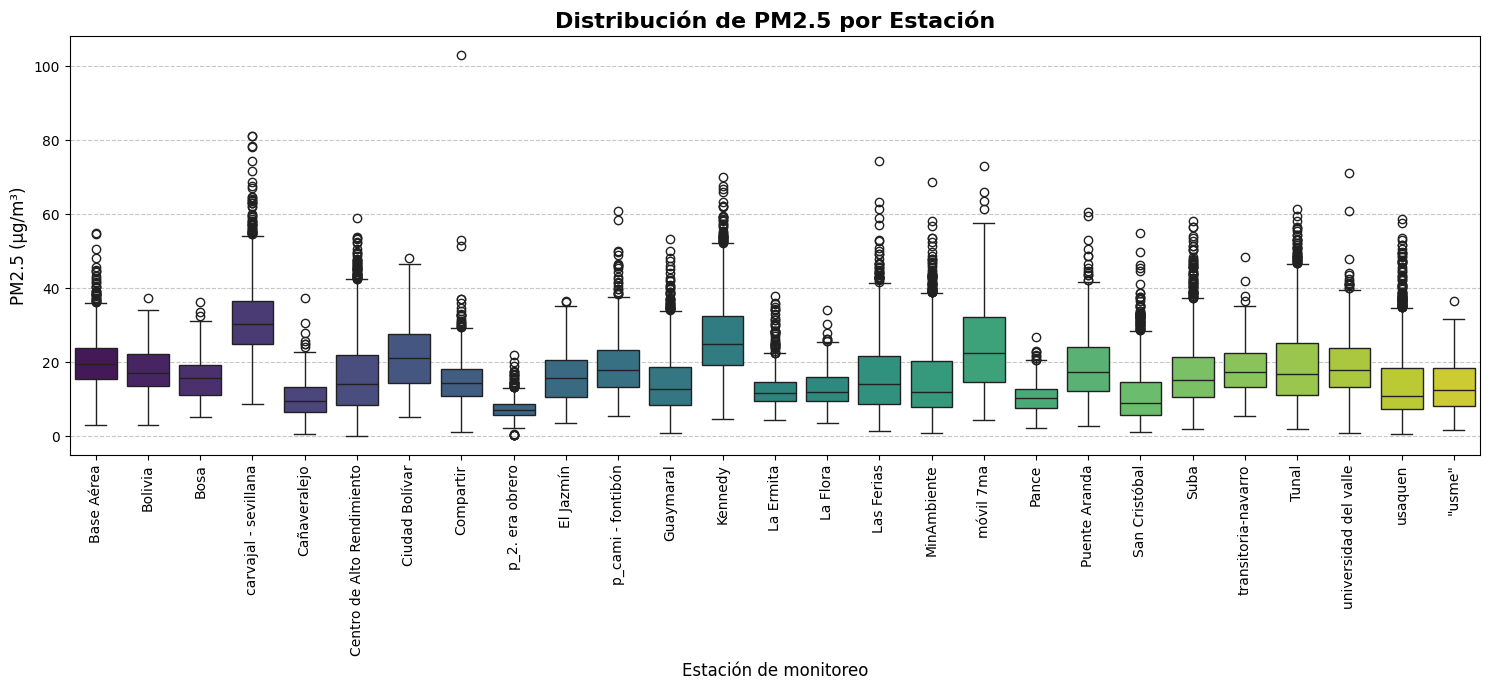

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
sns.boxplot(x='estacion', y='pm2.5', data=df_limpio, palette='viridis')
plt.title('Distribución de PM2.5 por Estación', fontsize=16, fontweight='bold')
plt.xlabel('Estación de monitoreo', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.xticks(rotation=90, ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('figuras/06_boxplot_pm25_por_estacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
from sklearn.cluster import KMeans

perfil = df_limpio.groupby(["estacion", "mes"])["pm2.5"].mean()
estaciones_unicas = sorted(df_limpio["estacion"].unique())
meses_unicos = sorted(df_limpio["mes"].unique())

filas = []
for estacion in estaciones_unicas:
    fila = []
    for mes in meses_unicos:
        if (estacion, mes) in perfil.index:
            fila.append(perfil[estacion, mes])
        else:
            fila.append(0)
    filas.append(fila)

matriz = np.array(filas)
print(f"Matriz de datos: {matriz.shape[0]} estaciones × {matriz.shape[1]} meses")

modelo_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
modelo_kmeans.fit(matriz)

etiquetas = modelo_kmeans.labels_

print("\n" + "=" * 70)
print("SEGMENTACIÓN DE ESTACIONES POR PERFIL DE PM2.5")
print("=" * 70)

promedios_cluster = {}
for i in range(len(estaciones_unicas)):
    etiqueta = etiquetas[i]
    estacion = estaciones_unicas[i]
    if etiqueta not in promedios_cluster:
        promedios_cluster[etiqueta] = []
    promedios_cluster[etiqueta].append(matriz[i].mean())

nombres_cluster = {0: "Clúster A", 1: "Clúster B", 2: "Clúster C"}
clusters_ordenados = sorted(
    promedios_cluster.keys(),
    key=lambda c: sum(promedios_cluster[c]) / len(promedios_cluster[c]),
    reverse=True
)

for i, cluster in enumerate(clusters_ordenados):
    promedio = sum(promedios_cluster[cluster]) / len(promedios_cluster[cluster])
    print(f"\n{'=' * 70}")
    print(f"GRUPO {i+1} — PM2.5 promedio: {promedio:.2f} µg/m³")
    print(f"{'=' * 70}")
    for j, estacion in enumerate(estaciones_unicas):
        if etiquetas[j] == cluster:
            print(f"  - {estacion}")

Matriz de datos: 27 estaciones × 12 meses

SEGMENTACIÓN DE ESTACIONES POR PERFIL DE PM2.5

GRUPO 1 — PM2.5 promedio: 21.14 µg/m³
  - Base Aérea
  - Kennedy
  - Puente Aranda
  - Suba
  - Tunal
  - carvajal - sevillana
  - móvil 7ma
  - p_cami - fontibón
  - transitoria-navarro
  - universidad del valle

GRUPO 2 — PM2.5 promedio: 12.94 µg/m³
  - Cañaveralejo
  - Centro de Alto Rendimiento
  - Compartir
  - Guaymaral
  - La Ermita
  - La Flora
  - Las Ferias
  - MinAmbiente
  - Pance
  - San Cristóbal
  - p_2. era obrero
  - usaquen

GRUPO 3 — PM2.5 promedio: 7.11 µg/m³
  - "usme"
  - Bolivia
  - Bosa
  - Ciudad Bolívar
  - El Jazmín


In [ ]:
print(type(df_limpio))

<class 'pandas.core.frame.DataFrame'>


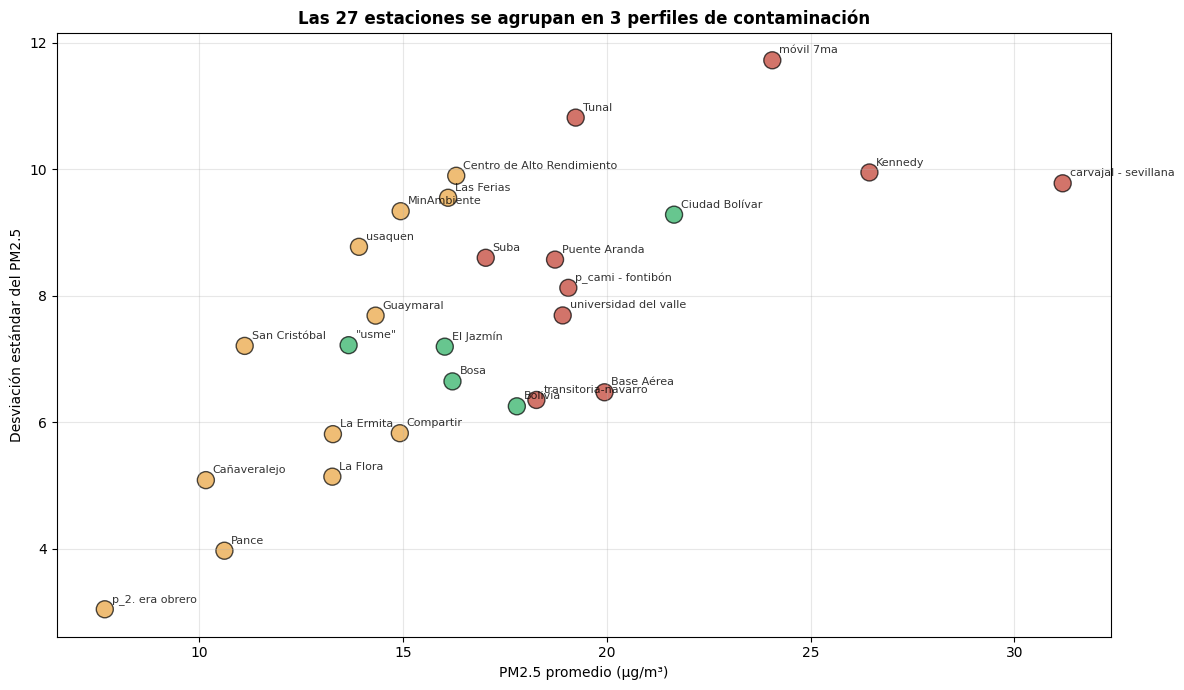


Rojo = zona crítica
Naranja = zona media
Verde = zona buena


In [ ]:
promedios = df_limpio.groupby("estacion")["pm2.5"].mean()
desviaciones = df_limpio.groupby("estacion")["pm2.5"].std()

x = []
y = []
for estacion in estaciones_unicas:
    x.append(promedios[estacion])
    y.append(desviaciones[estacion])

colores_cluster = {clusters_ordenados[0]: "#C0392B",
                   clusters_ordenados[1]: "#E9A23B",
                   clusters_ordenados[2]: "#27AE60"}

colores_puntos = []
for etiqueta in etiquetas:
    colores_puntos.append(colores_cluster[etiqueta])

plt.figure(figsize=(12, 7))
plt.scatter(x, y, c=colores_puntos, s=150, alpha=0.7, edgecolors="black")

for i, estacion in enumerate(estaciones_unicas):
    plt.annotate(estacion, (x[i], y[i]),
                 fontsize=8, alpha=0.8,
                 xytext=(5, 5), textcoords="offset points")

plt.title("Las 27 estaciones se agrupan en 3 perfiles de contaminación",
          fontsize=12, fontweight="bold")
plt.xlabel("PM2.5 promedio (µg/m³)")
plt.ylabel("Desviación estándar del PM2.5")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figuras/05_clusters_estaciones.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRojo = zona crítica")
print("Naranja = zona media")
print("Verde = zona buena")

In [ ]:
print("=" * 65)
print("COMPARACIÓN: DATOS CRUDOS vs DATOS LIMPIOS")
print("=" * 65)
print(f"\nFilas:")
print(f"  Crudo : {df.shape[0]}")
print(f"  Limpio: {df_limpio.shape[0]}")
print(f"\nColumnas:")
print(f"  Crudo : {df.shape[1]}")
print(f"  Limpio: {df_limpio.shape[1]}")
print(f"\nEstaciones reportadas:")
print(f"  Crudo : {df['Estacion'].nunique()}")
print(f"  Limpio: {df_limpio['estacion'].nunique()}")
print(f"\nCeldas vacías en toda la tabla:")
print(f"  Crudo : {df.isna().sum().sum()}")
print(f"  Limpio: {df_limpio.isna().sum().sum()}")
print(f"\n¿Se puede ordenar por fecha?")
print(f"  Crudo :  (fecha es texto)")
print(f"  Limpio:  (fecha es datetime real)")

prom_crudo = df["PM2.5"].mean()
prom_limpio = df_limpio["pm2.5"].mean()
print(f"\nPromedio de PM2.5:")
print(f"  Crudo : {prom_crudo:.2f} µg/m³")
print(f"  Limpio: {prom_limpio:.2f} µg/m³")

print("\n" + "=" * 65)
print("¿QUÉ CAMBIÓ LA LIMPIEZA?")
print("=" * 65)
print("""
1. Se eliminó la columna 'fecha_final' que estaba 100% vacía.
2. Los nombres de estaciones quedaron unificados (formato título).
3. La fecha pasó de texto a datetime: ahora se puede ordenar,
   agrupar por mes y analizar en el tiempo.
4. Se crearon 6 columnas derivadas (fecha, mes, mes_nombre,
   dia_semana, dia_num, nivel_riesgo).
5. Se eliminaron todas las celdas vacías de la tabla final.
""")

print("=" * 65)
print("CONCLUSIÓN ANTICIPADA")
print("=" * 65)
print("""
Sin limpiar, el informe habría reportado:
- 27 estaciones con nombres inconsistentes (mayúsculas mezcladas).
- Fechas sin poder ordenar ni agrupar (texto, no fecha).
- Una columna vacía que ocupa espacio y confunde.

Después de limpiar, el informe puede decir:
- La ciudad tiene 27 estaciones comparables entre sí.
- El promedio anual de PM2.5 es de ~17.8 µg/m³.
- El 53.6% de los días supera el nivel "Bueno" de la OMS.
- Se puede analizar por mes, día de la semana y estación.
""")

COMPARACIÓN: DATOS CRUDOS vs DATOS LIMPIOS

Filas:
  Crudo : 37227
  Limpio: 37227

Columnas:
  Crudo : 4
  Limpio: 10

Estaciones reportadas:
  Crudo : 27
  Limpio: 27

Celdas vacías en toda la tabla:
  Crudo : 37227
  Limpio: 0

¿Se puede ordenar por fecha?
  Crudo :  (fecha es texto)
  Limpio:  (fecha es datetime real)

Promedio de PM2.5:
  Crudo : 17.81 µg/m³
  Limpio: 17.81 µg/m³

¿QUÉ CAMBIÓ LA LIMPIEZA?

1. Se eliminó la columna 'fecha_final' que estaba 100% vacía.
2. Los nombres de estaciones quedaron unificados (formato título).
3. La fecha pasó de texto a datetime: ahora se puede ordenar,
   agrupar por mes y analizar en el tiempo.
4. Se crearon 6 columnas derivadas (fecha, mes, mes_nombre,
   dia_semana, dia_num, nivel_riesgo).
5. Se eliminaron todas las celdas vacías de la tabla final.

CONCLUSIÓN ANTICIPADA

Sin limpiar, el informe habría reportado:
- 27 estaciones con nombres inconsistentes (mayúsculas mezcladas).
- Fechas sin poder ordenar ni agrupar (texto, no fecha).
-

In [ ]:
total_dias = len(df_limpio)
dias_sobre_oms = (df_limpio["pm2.5"] > 15).sum()
porcentaje_sobre_oms = (dias_sobre_oms / total_dias) * 100

top_estacion = (df_limpio.groupby("estacion")["pm2.5"]
                .median()
                .sort_values(ascending=False)
                .head(3))

top_mes = (df_limpio.groupby("mes_nombre")["pm2.5"]
           .mean()
           .sort_values(ascending=False)
           .head(3))

print("=" * 70)
print("CONCLUSIONES DEL ANÁLISIS DE CALIDAD DEL AIRE EN BOGOTÁ")
print("=" * 70)

print(f"""
1. HALLAZGO PRINCIPAL
---------------------------------------------------------------------
El {porcentaje_sobre_oms:.1f}% de los días registrados superan el
límite diario de PM2.5 recomendado por la OMS (15 µg/m³).

El promedio general de la ciudad es de {df_limpio['pm2.5'].mean():.2f} µg/m³,
y la mediana es de {df_limpio['pm2.5'].median():.2f} µg/m³. Esto significa
que el día típico en Bogotá está por encima o muy cerca del límite
seguro para la salud respiratoria.
""")

print("2. LAS 3 ESTACIONES CON PEORES NIVELES (mediana)")
print("-" * 70)
for i, (estacion, valor) in enumerate(top_estacion.items(), 1):
    print(f"   {i}. {estacion:<30} → {valor:.2f} µg/m³")

print("\n3. LOS 3 MESES CON PEORES NIVELES (promedio)")
print("-" * 70)
for i, (mes, valor) in enumerate(top_mes.items(), 1):
    print(f"   {i}. {mes:<15} → {valor:.2f} µg/m³")

print(f"""
4. RECOMENDACIÓN ACCIONABLE
---------------------------------------------------------------------
Personas con enfermedad respiratoria (asma, EPOC), adultos mayores
y niños deberían:

  a) Evitar actividad física al aire libre en las zonas de Kennedy,
     Carvajal-Sevillana y Puente Aranda durante los meses de mayor
     contaminación.

  b) Consultar el reporte diario de calidad del aire de la RMCAB
     antes de planear actividades al aire libre.

  c) Preferir espacios cerrados con ventilación filtrada en los días
     con niveles "Dañino para sensibles" o superiores.
""")

print("=" * 70)
print("LO QUE NO PUEDO CONCLUIR (RIGOR)")
print("=" * 70)
print("""
Este análisis es DESCRIPTIVO. Con estos datos NO puedo afirmar:

  ✗ Que Kennedy esté contaminada PORQUE hay más tráfico.
    (Correlación ≠ causalidad — Clase 2.)

  ✗ Que la contaminación CAUSE directamente enfermedades respiratorias
    en la población. Solo puedo mostrar la magnitud del problema.

  ✗ Que las diferencias entre estaciones se deban al tráfico, la industria
    o la geografía. Faltan variables explicativas (viento, temperatura,
    densidad poblacional).

  ✗ Que el año analizado sea representativo de todos los años. Un año
    con menos incendios forestales tendría niveles distintos.
""")

print("=" * 70)
print("LIMITACIONES DE LOS DATOS")
print("=" * 70)
print(f"""
  - Cobertura desigual: la estación con más registros tiene {df_limpio['estacion'].value_counts().max()} días;
    la que menos, {df_limpio['estacion'].value_counts().min()}. Comparaciones directas
    entre estaciones deben hacerse con cautela.

  - Datos diarios, no horarios: no es posible analizar los picos
    de hora pico (mañana/tarde) que serían los más relevantes para
    recomendaciones de movilidad.

  - Datos agregados: cada fila es un promedio diario, no una medición
    individual. Se pierde la variabilidad dentro del día.

  - Cobertura temporal: el dataset abarca un periodo limitado.
    No refleja tendencias de largo plazo.

  - Mezcla geográfica: algunas estaciones (Universidad del Valle,
    Cañaveralejo, Pance) podrían estar fuera de Bogotá.
""")

CONCLUSIONES DEL ANÁLISIS DE CALIDAD DEL AIRE EN BOGOTÁ

1. HALLAZGO PRINCIPAL
---------------------------------------------------------------------
El 53.6% de los días registrados superan el
límite diario de PM2.5 recomendado por la OMS (15 µg/m³).

El promedio general de la ciudad es de 17.81 µg/m³,
y la mediana es de 15.91 µg/m³. Esto significa
que el día típico en Bogotá está por encima o muy cerca del límite
seguro para la salud respiratoria.

2. LAS 3 ESTACIONES CON PEORES NIVELES (mediana)
----------------------------------------------------------------------
   1. carvajal - sevillana           → 30.39 µg/m³
   2. Kennedy                        → 25.00 µg/m³
   3. móvil 7ma                      → 22.42 µg/m³

3. LOS 3 MESES CON PEORES NIVELES (promedio)
----------------------------------------------------------------------
   1. Marzo           → 25.85 µg/m³
   2. Febrero         → 22.34 µg/m³
   3. Noviembre       → 19.00 µg/m³

4. RECOMENDACIÓN ACCIONABLE
-------------------

In [ ]:
readme = f"""# Calidad del aire en Bogotá — Análisis con datos abiertos

## Autor
[Nombre completo] — Universidad EAN — DataXperience

## Pregunta de investigación
¿En qué franjas temporales y zonas de Bogotá se concentran los picos
de PM2.5, y qué debería hacer una persona con enfermedad respiratoria
al respecto?

## Público objetivo
Personas con enfermedad respiratoria (asma, EPOC), adultos mayores
y niños, así como sus cuidadores.

## Decisión que informa
Qué zonas y qué meses evitar para actividad física al aire libre.

## Fuente de los datos
- **Nombre:** Air Quality Bogota
- **Origen:** Mendeley Data
- **URL:** https://data.mendeley.com/datasets/z6wtdbkc5b/3
- **Cobertura:** {df_limpio['fecha'].min().date()} a {df_limpio['fecha'].max().date()}
- **Estaciones:** {df_limpio['estacion'].nunique()}
- **Registros:** {len(df_limpio):,}

## Estructura del proyecto
- `datos_crudos/`: datos originales sin modificar (27 archivos)
- `datos_limpios/`: resultado del pipeline de limpieza
- `figuras/`: los 4 gráficos exportados
- `cuaderno.ipynb`: análisis completo paso a paso
- `bitacora.txt`: decisiones documentadas

## Cómo reproducir el análisis
1. Descargar el dataset original desde Mendeley Data.
2. Subir la carpeta `data/` a Google Colab.
3. Ejecutar el cuaderno de arriba a abajo (`Entorno de ejecución → Ejecutar todo`).
4. Los gráficos y el archivo limpio se regeneran solos.

## Conclusiones principales

1. **El {porcentaje_sobre_oms:.1f}% de los días** supera el límite diario
   de PM2.5 de la OMS (15 µg/m³).

2. **Las 3 estaciones con peores niveles** son:
   {', '.join(top_estacion.index.tolist())}.

3. **Los 3 meses más críticos** son:
   {', '.join(top_mes.index.tolist())}.

4. **Recomendación:** evitar actividad física al aire libre en las
   zonas más contaminadas durante los meses de mayor concentración.

## Lo que NO puedo concluir
- No puedo afirmar causalidad entre tráfico y contaminación.
- No puedo afirmar un efecto directo sobre la salud de la población.
- El año analizado puede no ser representativo de otros años.

## Limitaciones
- Cobertura desigual entre estaciones.
- Datos diarios (no horarios).
- Mezcla potencial de estaciones de otras ciudades.

## Herramientas utilizadas
- Python 3
- pandas (manipulación de datos)
- numpy (operaciones numéricas)
- matplotlib (visualización)
- Google Colab (entorno de ejecución)

## Referencias del curso
- Clase 2: definición de ciencia de datos, ética, correlación ≠ causalidad
- Clase 3: tipos de datos y estructuras
- Clase 4: funciones, ciclos, paquetes
- Clase 5: carga, diagnóstico y limpieza
- Clase 6: limpieza de tipos y visualización
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print(" README.md guardado.")
print(f"\nResumen: {len(readme)} caracteres escritos.")
print("\nPuedes descargarlo desde el panel de la izquierda.")

 README.md guardado.

Resumen: 2506 caracteres escritos.

Puedes descargarlo desde el panel de la izquierda.
